<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4psy_2023/blob/main/11a_jax.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>

(jax-notebook)=
# Usare JAX e Nutpie per un campionamento più veloce

In precedenza, abbiamo utilizzato il campionatore predefinito fornito da PyMC. Tuttavia, esiste un'alternativa più efficiente che utilizza l'algoritmo NUTS (No-U-Turn Sampler) implementato con la libreria JAX. Questo campionatore è noto per la sua capacità di eseguire il campionamento in modo più veloce e efficiente. Una seconda alternativa è Nutpie. Nutpie è emerso nella seconda metà del 2022 come un'implementazione estremamente veloce in Rust di Hamiltonian Monte Carlo adattativo che può campionare dai posteriori dei modelli bayesiani specificati sia con PyMC che con Stan.

Per utilizzare queste opzione, è possibile seguire la procedura descritta in questo capitolo.

Prima di procedere, è necessario installare JAX e le librerie associate. Poiché NumPyro è una libreria che dipende da JAX, si può installare con il seguente comando Conda nell'ambiente virtuale dove abbiamo installato PyMC:

```bash
conda install -c conda-forge jax
conda install -c conda-forge numpyro
```

Dopo aver completato l'installazione, è possibile importare il modulo per il campionamento basato su JAX:

```python
import pymc.sampling_jax
```

Per installare Nutpie nell'ambiente virtuale, è necessario prima installare Numba. Successivamente, è possibile procedere con l'installazione di Nutpie tramite pip.

```bash
conda install -c conda-forge numba
pip install 'nutpie[stan]'
```

Per campionare da un modello Stan è necessario installare `bridgestan` tramite pip:

```bash
pip install bridgestan
```

Con questi passaggi, è possibile utilizzare i campionatori basati su JAX o [nutpie](https://github.com/pymc-devs/nutpie) per effettuare analisi più rapide ed efficienti.

## Preparazione del Notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import jax
import nutpie
import pymc.sampling_jax
import scipy.stats as stats
import seaborn as sns
import arviz as az
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=Warning)

/Users/corrado/opt/anaconda3/envs/pymc_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
sns.set_theme(palette="colorblind")

In [3]:
# We can control the number cores that are used by an environment variable:
import os
import multiprocessing

num_cores = multiprocessing.cpu_count()
os.environ["RAYON_NUM_THREADS"] = str(num_cores)

## Applicazioni

Per fare un esempio pratico, consideriamo nuovamente i dati relativi agli artisti della Generazione X nel MOMA. Ricordiamo che i dati corrispondono a 14 successi su 100 prove. Come in precedenza, imposteremo sul parametro $\theta$ (probabilità di appartenere alla Generazione X o successive) una distribuzione Beta(4, 6). Il modello, dunque, si presenta come:

$$
\begin{align}
y &\sim Bin(n, \theta) \notag\\
\theta &\sim Beta(4, 6)
\end{align}
$$ 

In [4]:
# Dati
y = 14
ntrials = 100

In [5]:
# Distribuzione a priori
alpha_prior = 4
beta_prior = 6

## Definire il modello

Il modello PyMC viene specificato esattamente come abbiamo fatto in precedenza.

In [6]:
model = pm.Model()

with model:
    # Prior
    theta = pm.Beta("theta", alpha=alpha_prior, beta=beta_prior)
    # Likelihood
    obs = pm.Binomial("obs", p=theta, n=ntrials, observed=y)

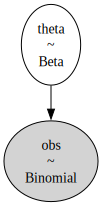

In [7]:
pm.model_to_graphviz(model)

## Esecuzione del campionamento

In precedenza, per il campionamento abbiamo usato la funzione `pm.sample()`.

In [8]:
%%time
with model:
    idata1 = pm.sample()

KeyboardInterrupt: 

Sul mio computer questo richiede circa 40 s.

Ripetiamo ora il campionamento, facendo ricorso al campionatore JAX. Per quel che riguarda il codice, useremo l'istruzione `pm.sampling_jax.sample_numpyro_nuts()`.

In [163]:
with model:
    idata2 = pm.sampling_jax.sample_numpyro_nuts()

Compiling...
Compilation time = 0:00:00.372838
Sampling...
Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:01<?, ?it/s]


Running chain 3: 100%|██████████| 2000/2000 [00:01<00:00, 1308.73it/s]
Sampling time = 0:00:01.643764
Transforming variables...
Transformation time = 0:00:00.040655


Si osservi che, nel caso in esame, il processo di campionamento ha impiegato solamente 2 secondi. Sebbene questa accelerazione possa sembrare trascurabile per modelli di semplice costruzione, assume un'importanza significativa quando si tratta di modelli più complessi. In scenari in cui il campionamento può richiedere ore di elaborazione, una diminuzione anche solo del 50% del tempo necessario può avere un impatto considerevole dal punto di vista pratico.

Una volta ottenuto l'oggetto `idata`, questo può essere manipolato come abbiamo fatto in precedenza. Per esempio, per produrre la traccia e la distribuzione a posteriori di $\theta$ chiamiamo `az.plot_trace()`.

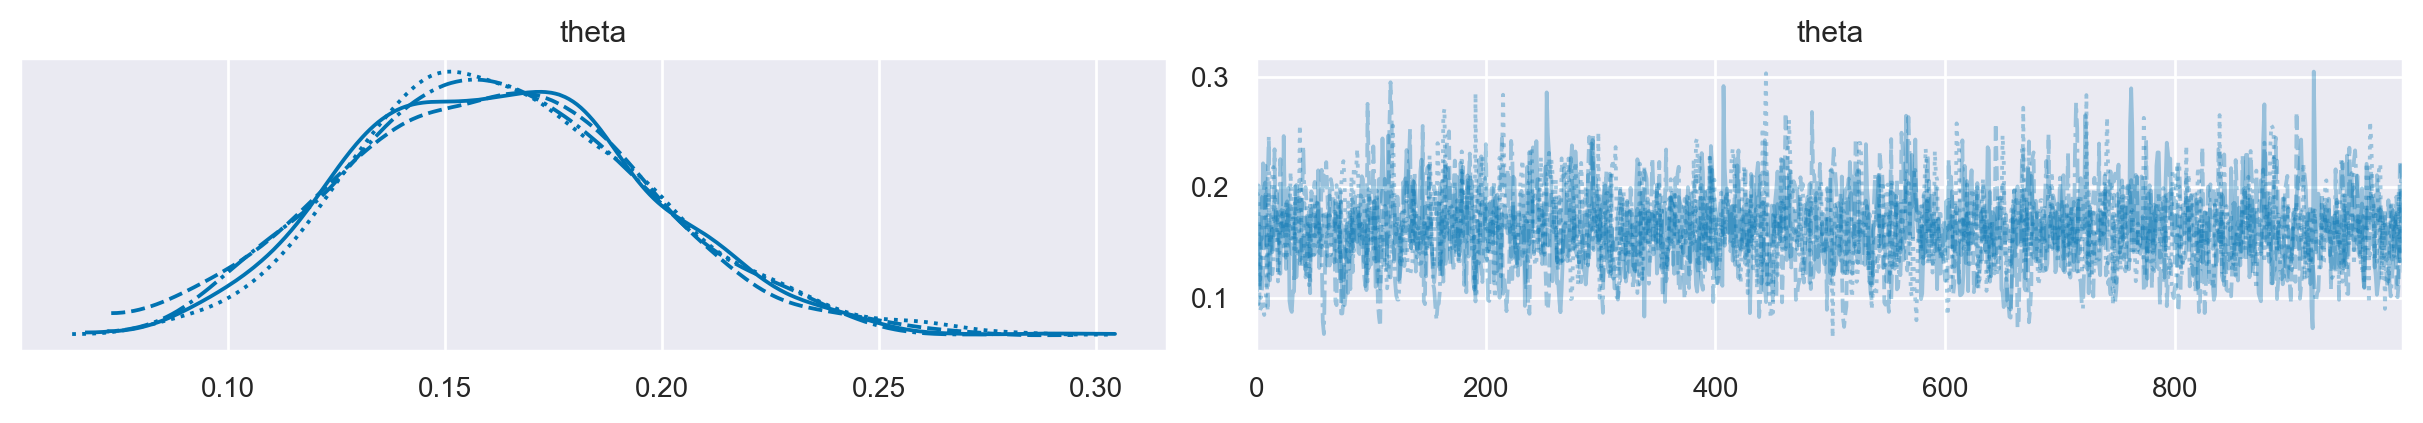

In [164]:
_ = az.plot_trace(idata2)

Per un sommario della distribuzione a posteriori usiamo `az.summary()`.

In [165]:
az.summary(idata2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.162,0.035,0.096,0.225,0.001,0.001,1676.0,1709.0,1.0


Ripetiamo un'altra volta il campionamento, facendo ricorso al campionatore `numpie`.

In [166]:
compiled_model = nutpie.compile_pymc_model(model)

In [167]:
idata3 = nutpie.sample(compiled_model)

In [176]:
with pm.Model() as model:
    theta = pm.Beta("theta", alpha=alpha_prior, beta=beta_prior)
    obs = pm.Binomial("obs", p=theta, n=ntrials, observed=y)
    idata3 = pm.sample(nuts_sampler='nutpie', target_accept=0.95)
    idata3 = pm.sample_posterior_predictive(idata3, extend_inferencedata=True)

Sampling: [obs]


`idata3` ora contiene un oggetto ArviZ `InferenceData`, che include le statistiche di campionamento e il posteriore delle variabili definite in precedenza.

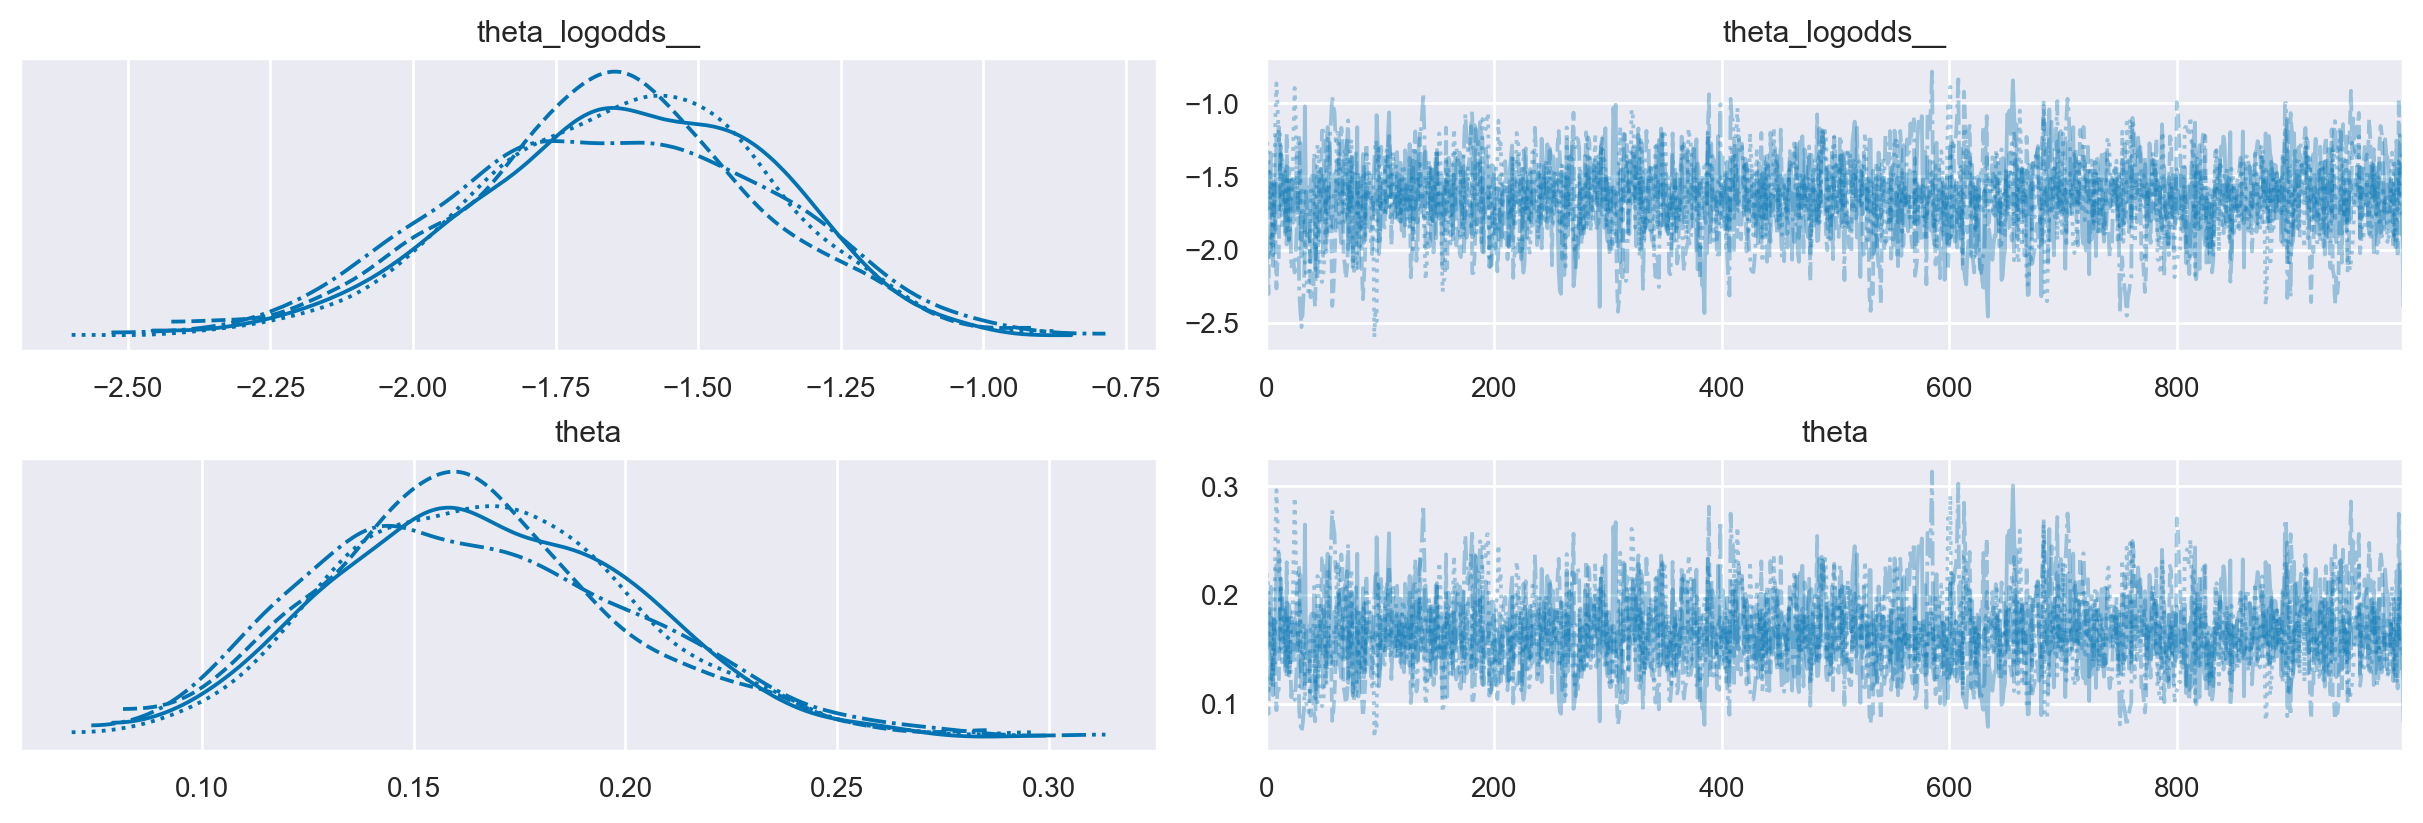

In [177]:
_ = az.plot_trace(idata3)

In [178]:
az.summary(idata3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_logodds__,-1.641,0.266,-2.133,-1.155,0.007,0.005,1345.0,1259.0,1.0
theta,0.165,0.036,0.100,0.233,0.001,0.001,1345.0,1259.0,1.0


### Nutpie e Stan

Nutpie può anche essere usato per compilare codice Stan. Il codice Stan per il modello beta-binomiale è il seguente.

In [12]:
beta_binomial_code = """
    data {
    int<lower=0> n_trials; // Number of trials
    int<lower=0> y_data; // Number of successes
    real<lower=0> alpha_prior; // Alpha parameter for the Beta prior
    real<lower=0> beta_prior; // Beta parameter for the Beta prior
    }

    parameters {
    real<lower=0, upper=1> theta; // Success probability
    }

    model {
    // Prior distribution for theta
    theta ~ beta(alpha_prior, beta_prior);
    
    // Likelihood of the observations
    y_data ~ binomial(n_trials, theta);
    }
"""

Usando nutpie, compiliamo il modello nel modo seguente.

In [13]:
compiled = nutpie.compile_stan_model(code=beta_binomial_code)

Passiamo i dati al modello compilato.

In [14]:
compiled_model_with_data = compiled.with_data(
    n_trials=100,
    y_data=14,
    alpha_prior=4,
    beta_prior=6
)

Eseguiamo il campionamento.

In [15]:
trace_stan = nutpie.sample(compiled_model_with_data, chains=4)

L'oggetto risultante è di classe InferenceData:

In [17]:
print (type(trace_stan).__name__)

InferenceData


Possiamo dunque usarlo con Arviz.

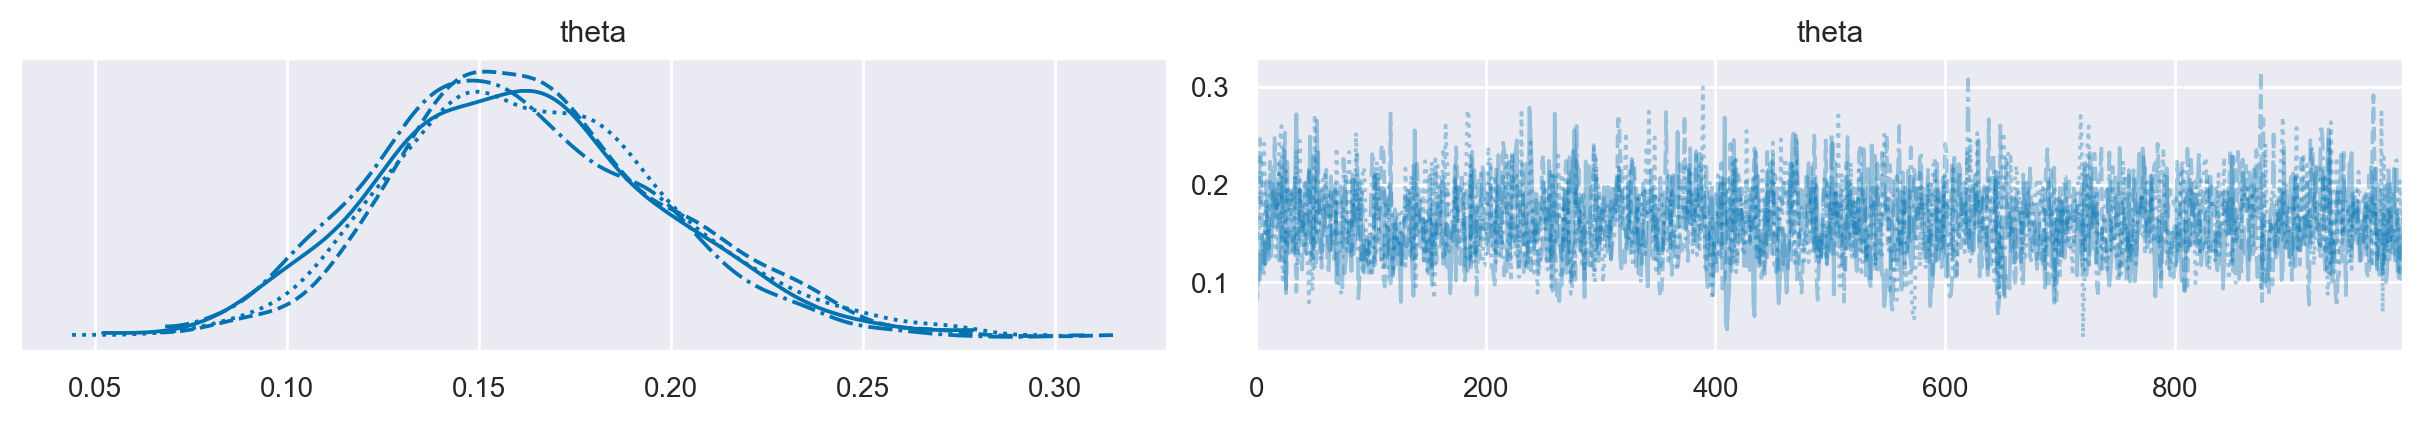

In [18]:
_ = az.plot_trace(trace_stan)

## Commenti e considerazioni finali 

Le implementazioni di JAX e Nutpie rappresentano un notevole progresso nel processo di campionamento di PyMC, offrendo soluzioni più veloci ed efficienti rispetto ai metodi convenzionali. La capacità di accelerare le operazioni di campionamento da parte di JAX e Nutpie consente una maggiore agilità nell'analisi, riducendo i tempi di attesa e agevolando l'esplorazione di modelli più complessi. Inoltre, la loro integrazione fluida con PyMC rende questi vantaggi accessibili senza richiedere modifiche al codice esistente.

## Watermark

In [19]:
%load_ext watermark
%watermark -n -u -v -iv -w -p nutpie -m

Last updated: Wed Feb 21 2024

Python implementation: CPython
Python version       : 3.11.7
IPython version      : 8.21.0

nutpie: 0.9.2

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.3.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

numpy     : 1.26.4
matplotlib: 3.8.2
pytensor  : 2.18.6
seaborn   : 0.13.2
jax       : 0.4.23
scipy     : 1.12.0
arviz     : 0.17.0
pymc      : 5.10.4
nutpie    : 0.9.2

Watermark: 2.4.3

